# ** ISTA 322 Final Project - Music Analysis ETL**

This ETL will create a comprehensive music analytics database that can analyze relationships between top chart success and critical acclaim in the music industry from the past decade (2015-2025). The ETL integrates datasets from Billboard Hot 100, Spotify Audio Features, and Grammy Awards.

The ETL extracts approximately 350,000 Billboard chart entries, 4,800 Grammy nominations, and 28,680 Spotify artist profiles. The ETL transforms this data by standardizing artist names across sources, generating unique artist IDs, and aggregating records into artist-level metrics.

The data is loaded into an AWS PostgreSQL database with three tables, which are artist_master (table with aggregated metrics), chart_performance (table with weekly chart detail), and grammy_nominations (table with individual nomination records).

This ETL can answer queries such as:

*   Do Grammy winners have better chart performance?
*   What audio features correlate with commercial success?
*   Do more energetic songs correlate with better peak positions?

###Data Sources


Spotify Artist Audio Features: https://www.kaggle.com/datasets/vatsalmavani/spotify-dataset/data

Grammy Awards: https://www.kaggle.com/datasets/unanimad/grammy-awards/data

Billboard Data: https://github.com/HipsterVizNinja/random-data/tree/main/Music/hot-100

### Diagrams/Schemas of Original and Final Tables

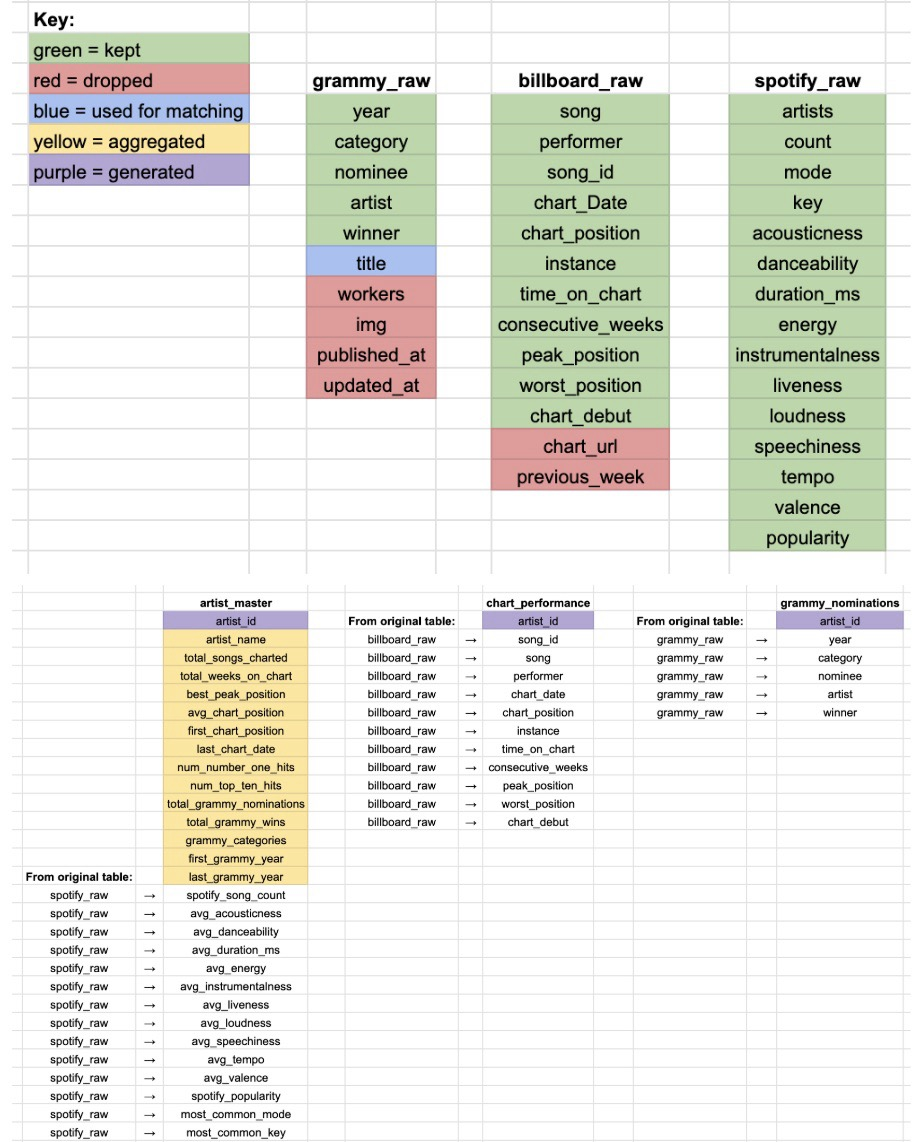

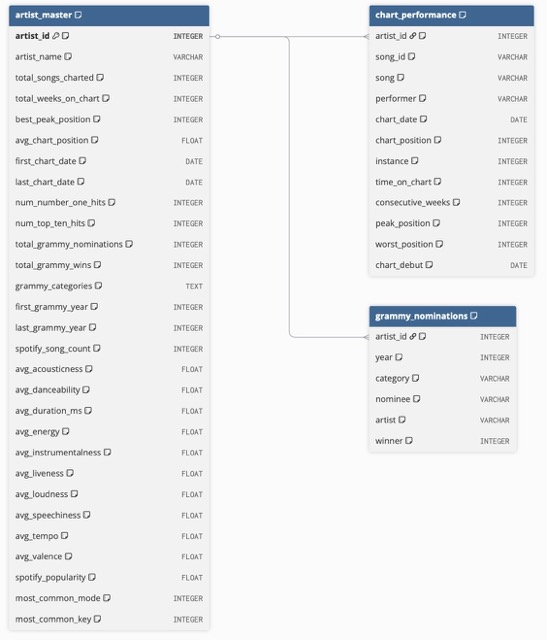

# Extract

In [ ]:
# Import necessary modules
import pandas as pd
import numpy as np
import datetime
import re

### Load and explore raw data from Billboard Hot 100, Grammy Awards, and Spotify

Here we will display each dataset and explore using interactive tables, check for data quality issues (NaNs, encoding, etc.), understand what each column represents, decide what to keep/drop with clear justifications, and rename columns for consistency.

Billboard Hot 100 raw data

In [ ]:
# Load Billboard Hot 100 data
billboard_raw = pd.read_csv('https://ista322musicetl.s3.us-east-2.amazonaws.com/Hot+100.csv')

In [ ]:
# Check shape of Billboard Hot 100 data
billboard_raw.shape

(350583, 13)

Note: There is over 350,000 rows of data here. We want to only span a decade of data in order to ensure the end user is able to access it, as the full database loading phase will take more + 20 hours to load. Additionally, the goal of this ETL is focused on recent popular music and artists.

In [ ]:
# Filter data between 2015-2025
billboard_raw['chart_date'] = pd.to_datetime(billboard_raw['chart_date'])
billboard_raw = billboard_raw[billboard_raw['chart_date'] >= '2015-01-01'].copy()
billboard_raw.shape[0]

56201

In [ ]:
# Explore raw data through interactive tab
billboard_raw

,chart_position,chart_date,song,performer,song_id,instance,time_on_chart,consecutive_weeks,previous_week,peak_position,worst_position,chart_debut,chart_url
139,71,2015-10-10,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,1,1,1,NaN,71,71,2015-10-10,https://www.billboard.com/charts/hot-100/2015-...
140,98,2015-10-31,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,2,2,1,NaN,71,98,2015-10-10,https://www.billboard.com/charts/hot-100/2015-...
141,100,2015-11-07,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,2,3,2,98.0,71,100,2015-10-10,https://www.billboard.com/charts/hot-100/2015-...
142,94,2015-11-14,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,2,4,3,100.0,71,100,2015-10-10,https://www.billboard.com/charts/hot-100/2015-...
143,89,2015-11-21,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,2,5,4,94.0,71,100,2015-10-10,https://www.billboard.com/charts/hot-100/2015-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
350574,38,2025-08-02,Yukon,Justin Bieber,yukon|justin bieber,1,2,2,17.0,17,38,2025-07-26,https://www.billboard.com/charts/hot-100/2025-...
350575,40,2025-08-09,Yukon,Justin Bieber,yukon|justin bieber,1,3,3,38.0,17,40,2025-07-26,https://www.billboard.com/charts/hot-100/2025-...
350576,32,2025-08-16,Yukon,Justin Bieber,yukon|justin bieber,1,4,4,40.0,17,40,2025-07-26,https://www.billboard.com/charts/hot-100/2025-...
350577,27,2025-08-23,Yukon,Justin Bieber,yukon|justin bieber,1,5,5,32.0,17,40,2025-07-26,https://www.billboard.com/charts/hot-100/2025-...


In [ ]:
# Check datatypes for each column
billboard_raw.dtypes

,0
chart_position,int64
chart_date,datetime64[ns]
song,object
performer,object
song_id,object
instance,int64
time_on_chart,int64
consecutive_weeks,int64
previous_week,float64
peak_position,int64


In [ ]:
# Check for missing values
billboard_raw.isnull().sum()

,0
chart_position,0
chart_date,0
song,0
performer,0
song_id,0
instance,0
time_on_chart,0
consecutive_weeks,0
previous_week,7962
peak_position,0


In [ ]:
# Check for statistics
billboard_raw.describe()

,chart_position,chart_date,instance,time_on_chart,consecutive_weeks,previous_week,peak_position,worst_position
count,56201.000000,56201,56201.000000,56201.000000,56201.000000,48239.000000,56201.000000,56201.000000
mean,50.499564,2020-05-20 00:04:09.048949504,1.326791,12.270013,10.845163,46.333320,35.963755,73.167150
min,1.000000,2015-01-03 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,26.000000,2017-09-09 00:00:00,1.000000,4.000000,3.000000,22.000000,10.000000,55.000000
50%,50.000000,2020-05-23 00:00:00,1.000000,9.000000,8.000000,45.000000,31.000000,84.000000
75%,75.000000,2023-01-28 00:00:00,1.000000,17.000000,16.000000,69.000000,58.000000,95.000000
max,100.000000,2025-08-30 00:00:00,14.000000,104.000000,90.000000,100.000000,100.000000,100.000000
std,28.866255,NaN,0.893871,11.331096,10.349720,27.678917,28.523857,27.084268


In [ ]:
# Check for duplicates
billboard_raw.duplicated().sum()

np.int64(0)

In [ ]:
# Check the date range
print(f"Earliest: {billboard_raw['chart_date'].min()}")
print(f"Latest: {billboard_raw['chart_date'].max()}")

Earliest: 2015-01-03 00:00:00
Latest: 2025-08-30 00:00:00


In [ ]:
# Check for problematic entries
print(f"Entries with missing 'song': {billboard_raw['song'].isnull().sum()}")
print(f"Entries with missing 'performer': {billboard_raw['performer'].isnull().sum()}")

Entries with missing 'song': 0
Entries with missing 'performer': 0


The following columns will be dropped:

First, chart_url is a URL link to Billboard.com. Many of the links don't work or lead to an error page. Additionally, these URL links do not provide analytical value and are not needed for the music characteristics analysis.


Second, previous_week shows the chart position from the previous
week and has thousands of missing values. This information is redundant as it can be derived from the chart_position values for each song_id. Additionally, the analysis focuses on overall chart performance metrics (peak position,
time on chart, consecutive weeks) rather than week-to-week movement
patterns, so this column is not needed.

In [ ]:
# Save the Billboard raw data into a new table
billboard_cols_dropped = billboard_raw.copy(deep=True)

In [ ]:
# Drop unnecessary columns
billboard_cols_dropped = billboard_cols_dropped.drop(['chart_url', 'previous_week'], axis='columns')

In [ ]:
# Check that unnecessary columns dropped
billboard_cols_dropped.columns

Index(['chart_position', 'chart_date', 'song', 'performer', 'song_id',
       'instance', 'time_on_chart', 'consecutive_weeks', 'peak_position',
       'worst_position', 'chart_debut'],
      dtype='object')

In [ ]:
# Check new shape
billboard_cols_dropped.shape

(56201, 11)

Grammy Awards raw data

In [ ]:
# Load Grammy Awards data
grammy_raw = pd.read_csv('https://ista322musicetl.s3.us-east-2.amazonaws.com/the_grammy_awards.csv')

In [ ]:
# Explore raw Grammy Awards data through interactive tab
grammy_raw

,year,title,published_at,updated_at,category,nominee,artist,workers,img,winner
0,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Bad Guy,Billie Eilish,"Finneas O'Connell, producer; Rob Kinelski & Fi...",https://www.grammy.com/sites/com/files/styles/...,True
1,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,"Hey, Ma",Bon Iver,"BJ Burton, Brad Cook, Chris Messina & Justin V...",https://www.grammy.com/sites/com/files/styles/...,True
2,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,7 rings,Ariana Grande,"Charles Anderson, Tommy Brown, Michael Foster ...",https://www.grammy.com/sites/com/files/styles/...,True
3,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Hard Place,H.E.R.,"Rodney “Darkchild” Jerkins, producer; Joseph H...",https://www.grammy.com/sites/com/files/styles/...,True
4,2019,62nd Annual GRAMMY Awards (2019),2020-05-19T05:10:28-07:00,2020-05-19T05:10:28-07:00,Record Of The Year,Talk,Khalid,"Disclosure & Denis Kosiak, producers; Ingmar C...",https://www.grammy.com/sites/com/files/styles/...,True
...,...,...,...,...,...,...,...,...,...,...
4805,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Instrumentalist (...,Tchaikovsky: Piano Concerto No. 1 In B Flat Mi...,NaN,"Van Cliburn, artist (Symphony Of The Air Orche...",NaN,True
4806,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Instrumentalist (...,Segovia Golden Jubilee,NaN,"Andres Segovia, artist",https://www.grammy.com/sites/com/files/styles/...,True
4807,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Chamber Music (In...,Beethoven: Quartet 130,NaN,"Hollywood String Quartet (Alvin Dinkin, Paul S...",NaN,True
4808,1958,1st Annual GRAMMY Awards (1958),2017-11-28T00:03:45-08:00,2019-09-10T01:11:09-07:00,Best Classical Performance - Vocal Soloist (Wi...,Operatic Recital,NaN,NaN,NaN,True


In [ ]:
# Check datatypes for each column
grammy_raw.dtypes

,0
year,int64
title,object
published_at,object
updated_at,object
category,object
nominee,object
artist,object
workers,object
img,object
winner,bool


In [ ]:
# Check for missing values
grammy_raw.isnull().sum()

,0
year,0
title,0
published_at,0
updated_at,0
category,0
nominee,6
artist,1840
workers,2190
img,1367
winner,0


Out of 4,810 rows, there are 1,840 artists missing. This means that there is 2,970 artists in the dataset.

In [ ]:
# Check for statistics
grammy_raw.describe()

,year
count,4810.000000
mean,1995.566944
std,17.149720
min,1958.000000
25%,1983.000000
50%,1998.000000
75%,2010.000000
max,2019.000000


In [ ]:
# Check to see the top 20 categories with missing artists
print(grammy_raw[grammy_raw['artist'].isnull()]['category'].value_counts().head(20))

category
Song Of The Year                             70
Best Opera Recording                         64
Best Album Notes                             63
Best Instrumental Composition                55
Best Country Song                            55
Best New Artist                              50
Best Historical Album                        44
Best Chamber Music Performance               43
Best Instrumental Arrangement                39
Best Orchestral Performance                  36
Best Classical Album                         35
Best Rock Song                               33
Best Recording Package                       32
Best Rhythm & Blues Song                     32
Best Choral Performance                      30
Best Engineered Album, Classical             28
Producer Of The Year, Non-Classical          27
Producer Of The Year, Classical              27
Best Engineered Recording - Non-Classical    25
Best R&B Song                                24
Name: count, dtype: int64


The following columns will be dropped:

First, workers has 2,190 missing values and represents other contributors on a song (engineers, producers, etc.) which our not relevant for the music characteristics analysis.

Second, img has 1,367 missing values and contains image URLs which also provide no analytical value for the end user.

Lastly, published_at and updated_at are timestamps when the dataset was published or updated, so this is not information about the music or awards. Additionally, the year column already provides the date information needed (when the Grammy Awards ceremony happened).

In [ ]:
# Save the Grammy raw data into a new table
grammy_cols_dropped = grammy_raw.copy(deep=True)

In [ ]:
# Drop unnecessary columns
grammy_cols_dropped = grammy_cols_dropped.drop(['workers', 'img', 'published_at', 'updated_at'], axis='columns')

In [ ]:
# Check that unnecessary columns dropped
grammy_cols_dropped.columns

Index(['year', 'title', 'category', 'nominee', 'artist', 'winner'], dtype='object')

The following row will be dropped:

All rows where artist is NULL (1840 rows). This is because we would not be able to match Grammy nominations to Billboard songs without artist names. The matching process will need both the song title and the artist name to correctly identify songs across datasets.

Additionally, some categories in category will be dropped because they are not in regards to popular music and artists (names that would appear in Billboard). These include Technical/production awards (Best Album Notes, Best Engineered Album, Producer of the Year, etc.), as these don't relate to song characteristics. Classical/Opera categories are also outside the scope of popular music analysis and Best Recording Package is about album artwork, not music.


In [ ]:
# Filter to only keep rows with artist data
grammy_with_artists = grammy_cols_dropped[grammy_cols_dropped['artist'].notna()].copy()

In [ ]:
# Check new shape of Grammy data
grammy_with_artists.shape

(2970, 6)

In [ ]:
# Ensure song-related categories are kept
song_categories_to_keep = [
    'Record Of The Year',
    'Album Of The Year',
    'Best Pop Solo Performance',
    'Best Pop Duo/Group Performance',
    'Best Pop Vocal Album',
    'Best Rock Performance',
    'Best Rock Song',
    'Best Rock Album',
    'Best Alternative Music Album',
    'Best R&B Performance',
    'Best R&B Song',
    'Best R&B Album',
    'Best Rap Performance',
    'Best Rap Song',
    'Best Rap Album',
    'Best Country Song',
    'Best Country Solo Performance',
    'Best Country Album',
    'Best Dance/Electronic Recording',
    'Best Dance/Electronic Music Album',
    'Best New Artist',
]


In [ ]:
# Check which categories are in the Grammy data
available_categories = grammy_with_artists['category'].unique()
matching_categories = [cat for cat in song_categories_to_keep if cat in available_categories]
for cat in matching_categories:
    count = len(grammy_with_artists[grammy_with_artists['category'] == cat])
    print(f"{cat}: {count} entries")

Record Of The Year: 69 entries
Album Of The Year: 66 entries
Best Pop Solo Performance: 13 entries
Best Pop Duo/Group Performance: 13 entries
Best Pop Vocal Album: 24 entries
Best Rock Performance: 13 entries
Best Rock Album: 30 entries
Best Alternative Music Album: 27 entries
Best R&B Performance: 13 entries
Best R&B Album: 30 entries
Best Rap Performance: 16 entries
Best Rap Album: 29 entries
Best Country Solo Performance: 13 entries
Best Country Album: 30 entries
Best New Artist: 1 entries


In [ ]:
# Filter to keep only song-related categories
grammy_cleaned = grammy_with_artists[grammy_with_artists['category'].isin(song_categories_to_keep)].copy()

In [ ]:
# Check new shape
grammy_cleaned.shape

(387, 6)

Spotify audio features raw data

In [ ]:
spotify_raw = pd.read_csv('https://ista322musicetl.s3.us-east-2.amazonaws.com/spotify_data_by_artist.csv')

In [ ]:
# Explore raw Spotify audio features data through interactive tab
spotify_raw

,mode,count,acousticness,artists,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,1,9,0.590111,"""Cats"" 1981 Original London Cast",0.467222,250318.555556,0.394003,0.011400,0.290833,-14.448000,0.210389,117.518111,0.389500,38.333333,5
1,1,26,0.862538,"""Cats"" 1983 Broadway Cast",0.441731,287280.000000,0.406808,0.081158,0.315215,-10.690000,0.176212,103.044154,0.268865,30.576923,5
2,1,7,0.856571,"""Fiddler On The Roof” Motion Picture Chorus",0.348286,328920.000000,0.286571,0.024593,0.325786,-15.230714,0.118514,77.375857,0.354857,34.857143,0
3,1,27,0.884926,"""Fiddler On The Roof” Motion Picture Orchestra",0.425074,262890.962963,0.245770,0.073587,0.275481,-15.639370,0.123200,88.667630,0.372030,34.851852,0
4,1,7,0.510714,"""Joseph And The Amazing Technicolor Dreamcoat""...",0.467143,270436.142857,0.488286,0.009400,0.195000,-10.236714,0.098543,122.835857,0.482286,43.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28675,1,2,0.512000,麥志誠,0.356000,198773.000000,0.306000,0.008970,0.108000,-10.119000,0.027700,150.049000,0.328000,35.000000,10
28676,0,2,0.541000,黃品源,0.578000,293840.000000,0.334000,0.000006,0.067500,-11.974000,0.026700,135.934000,0.243000,48.000000,9
28677,1,11,0.785455,黃國隆,0.570818,174582.727273,0.148400,0.000083,0.142191,-21.610091,0.054355,119.586273,0.741273,23.000000,5
28678,1,2,0.381000,黑豹,0.353000,316160.000000,0.686000,0.000000,0.056800,-9.103000,0.039500,200.341000,0.352000,35.000000,11


In [ ]:
# Check datatypes for each column
spotify_raw.dtypes

,0
mode,int64
count,int64
acousticness,float64
artists,object
danceability,float64
duration_ms,float64
energy,float64
instrumentalness,float64
liveness,float64
loudness,float64


In [ ]:
# Check for missing values
spotify_raw.isnull().sum()

,0
mode,0
count,0
acousticness,0
artists,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0
liveness,0
loudness,0


In [ ]:
# Check for statistics
spotify_raw.describe()

,mode,count,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
count,28680.000000,28680.000000,28680.000000,28680.000000,2.868000e+04,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000,28680.000000
mean,0.759170,13.847211,0.498373,0.546490,2.388780e+05,0.497488,0.174756,0.202441,-11.140498,0.094014,115.844830,0.512723,34.060945,5.412901
std,0.427595,53.372544,0.370614,0.176474,1.211318e+05,0.254885,0.298406,0.140884,5.771749,0.111986,25.003834,0.244421,22.376438,3.480552
min,0.000000,1.000000,0.000000,0.000000,1.879550e+04,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,0.122296,0.431000,1.823304e+05,0.283568,0.000004,0.110362,-13.972292,0.039200,99.366500,0.329000,12.000000,2.000000
50%,1.000000,3.000000,0.478458,0.557000,2.186400e+05,0.504000,0.001880,0.161000,-10.088938,0.052200,115.357400,0.523243,39.000000,6.000000
75%,1.000000,8.000000,0.896000,0.675000,2.684670e+05,0.702783,0.215291,0.247000,-6.889000,0.095300,129.848750,0.703000,51.000000,8.000000
max,1.000000,3169.000000,0.996000,0.986000,5.403500e+06,1.000000,1.000000,0.991000,1.342000,0.964000,217.743000,0.991000,93.000000,11.000000


In [ ]:
# Check for unique artists (entries should equal unique artists)
print(f"Total entries: {len(spotify_raw)}")
print(f"Unique artists: {spotify_raw['artists'].nunique()}")

Total entries: 28680
Unique artists: 28680


In [ ]:
# Check the audio feature statistics
print(spotify_raw[['acousticness', 'danceability', 'energy', 'instrumentalness',
                   'liveness', 'loudness', 'speechiness', 'tempo', 'valence']].describe())

       acousticness  danceability        energy  instrumentalness  \
count  28680.000000  28680.000000  28680.000000      28680.000000   
mean       0.498373      0.546490      0.497488          0.174756   
std        0.370614      0.176474      0.254885          0.298406   
min        0.000000      0.000000      0.000000          0.000000   
25%        0.122296      0.431000      0.283568          0.000004   
50%        0.478458      0.557000      0.504000          0.001880   
75%        0.896000      0.675000      0.702783          0.215291   
max        0.996000      0.986000      1.000000          1.000000   

           liveness      loudness   speechiness         tempo       valence  
count  28680.000000  28680.000000  28680.000000  28680.000000  28680.000000  
mean       0.202441    -11.140498      0.094014    115.844830      0.512723  
std        0.140884      5.771749      0.111986     25.003834      0.244421  
min        0.000000    -60.000000      0.000000      0.000000     

There will be no columns to drop, as all columns provide value for the ETL. Additionally, there are no missing values and all the audio features are in expected ranges, so the data quality is adequate.

In [ ]:
# Save the Spotify raw data into a new table
spotify_cleaned = spotify_raw.copy(deep=True)

# Transform

Here we will transform the cleaned exploration data into a normalized and
integrated dataset. We will create name lookup tables for each data source, manually verify and standardize artist names across sources, generate unique artist_id using pd.factorize, merge the lookup tables back to original data, aggregate data by artist, and create normalized tables for the future loading phase.


In [ ]:
# Create artist name tables

#Billboard artist names
billboard_artist_names = pd.DataFrame({
    'name': billboard_cols_dropped['performer'],
    'name_billboard': billboard_cols_dropped['performer']
})

# Grammy artist names
grammy_artist_names = pd.DataFrame({
    'name': grammy_cleaned['artist'],
    'name_grammy': grammy_cleaned['artist']
})

# Spotify artist names
spotify_artist_names = pd.DataFrame({
    'name': spotify_cleaned['artists'],
    'name_spotify': spotify_cleaned['artists']
})

Merge Billboard and Grammy artist names

In [ ]:
# Merge Billboard and Grammy names
bg_artist_names = billboard_artist_names.merge(
    grammy_artist_names,
    on='name',
    how='outer',
    indicator=True
)

print(f"Total unique names: {len(bg_artist_names)}")
print(f"In both Billboard & Grammy: {len(bg_artist_names[bg_artist_names._merge == 'both'])}")
print(f"Only in Billboard: {len(bg_artist_names[bg_artist_names._merge == 'left_only'])}")
print(f"Only in Grammy: {len(bg_artist_names[bg_artist_names._merge == 'right_only'])}")

# Create name_verified column
bg_artist_names['name_verified'] = pd.NA

# For names that appear in both, use them as is
bg_artist_names['name_verified'][bg_artist_names._merge == 'both'] = bg_artist_names['name'][bg_artist_names._merge == 'both']


Total unique names: 72024
In both Billboard & Grammy: 24386
Only in Billboard: 47403
Only in Grammy: 235


/tmp/ipython-input-2669663986.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  bg_artist_names['name_verified'][bg_artist_names._merge == 'both'] = bg_artist_names['name'][bg_artist_names._merge == 'both']
/tmp/ipython-input-2669663986.p

We will need to clean artist names to ensure they are consistent across datasets. For example, Beyonce vs Beyoncé or featured artists, (feat. artist). We will first create a cleaning function, apply it to all artist names, use cleaned names for matching, and keep original names for reference.

In [ ]:
# Handle name variations through a cleaning function and dictionaries
def clean_artist_name(name):
    if pd.isna(name):
        return ""

# Convert to string and strip whitespace
    name = str(name).strip()

# Remove featured artist tags
    patterns = [
        r'\(feat\..*?\)',
        r'\(featuring.*?\)',
        r'\(ft\..*?\)',
        r'featuring.*',
        r'feat\..*',
        r'ft\..*'
    ]
    for pattern in patterns:
        name = re.sub(pattern, '', name, flags=re.IGNORECASE)

# Strip again after removing features
    name = name.strip()

# Lowercase for consistency
    name = name.lower()

# Remove special characters but keep spaces
    name = re.sub(r'[^\w\s]', '', name)

# Collapse multiple spaces
    name = ' '.join(name.split())

    return name

In [ ]:
# Apply cleaning to all name columns
bg_artist_names['name_clean'] = bg_artist_names['name'].apply(clean_artist_name)
bg_artist_names['name_billboard_clean'] = bg_artist_names['name_billboard'].apply(clean_artist_name)
bg_artist_names['name_grammy_clean'] = bg_artist_names['name_grammy'].apply(clean_artist_name)

In [ ]:
# Build a mapping of cleaned Grammy names to original names
grammy_only = bg_artist_names[bg_artist_names._merge == 'right_only']
grammy_clean_to_original = dict(zip(grammy_only['name_grammy_clean'], grammy_only['name_grammy']))

# Build a mapping of cleaned Billboard names to original names
billboard_only = bg_artist_names[bg_artist_names._merge == 'left_only']

matched_count = 0
for idx, row in billboard_only.iterrows():
    if pd.notna(row['name_clean']) and row['name_clean'] != '':
# Check if cleaned name exists in Grammy
        if row['name_clean'] in grammy_clean_to_original:
            bg_artist_names.at[idx, 'name_verified'] = row['name_billboard']
# Find and update the corresponding Grammy entry
            grammy_idx = bg_artist_names[
                (bg_artist_names['name_grammy_clean'] == row['name_clean']) &
                (bg_artist_names._merge == 'right_only')
            ].index[0]
            bg_artist_names.at[grammy_idx, 'name_verified'] = row['name_billboard']
            matched_count += 1

In [ ]:
# Print the number of additional artists matched using cleaned names
matched_count

136

In [ ]:
# For remaining unmatched, use original names
# Billboard-only entries
unmatched_billboard = bg_artist_names[
    (bg_artist_names._merge == 'left_only') &
    (bg_artist_names.name_verified.isna())
]
for idx in unmatched_billboard.index:
    bg_artist_names.at[idx, 'name_verified'] = bg_artist_names.at[idx, 'name_billboard']

# Grammy-only entries
unmatched_grammy = bg_artist_names[
    (bg_artist_names._merge == 'right_only') &
    (bg_artist_names.name_verified.isna())
]
for idx in unmatched_grammy.index:
    bg_artist_names.at[idx, 'name_verified'] = bg_artist_names.at[idx, 'name_grammy']

print(f"Total names verified: {bg_artist_names.name_verified.notna().sum()}")

Total names verified: 72024


In [ ]:
# Print examples to verify matching
print(bg_artist_names[['name_billboard', 'name_grammy', 'name_verified', '_merge']].head(14))

       name_billboard name_grammy      name_verified     _merge
0   $NOT & A$AP Rocky         NaN  $NOT & A$AP Rocky  left_only
1         $uicideboy$         NaN        $uicideboy$  left_only
2         $uicideboy$         NaN        $uicideboy$  left_only
3         $uicideboy$         NaN        $uicideboy$  left_only
4         $uicideboy$         NaN        $uicideboy$  left_only
5         $uicideboy$         NaN        $uicideboy$  left_only
6         $uicideboy$         NaN        $uicideboy$  left_only
7         $uicideboy$         NaN        $uicideboy$  left_only
8         $uicideboy$         NaN        $uicideboy$  left_only
9         $uicideboy$         NaN        $uicideboy$  left_only
10        $uicideboy$         NaN        $uicideboy$  left_only
11        $uicideboy$         NaN        $uicideboy$  left_only
12        $uicideboy$         NaN        $uicideboy$  left_only
13        $uicideboy$         NaN        $uicideboy$  left_only


Merge Billboard and Grammy names with Spotify

In [ ]:
# Merge Billboard/Grammy verified names with Spotify
spotify_artist_names['name_clean'] = spotify_artist_names['name'].apply(clean_artist_name)

In [ ]:
# Get unique verified names from bg_artist_names
bg_unique = bg_artist_names[['name_verified', 'name_clean']].drop_duplicates()
bg_unique = bg_unique.rename(columns={'name_verified': 'name', 'name_clean': 'name_clean_bg'})

# Rename Spotify clean column
spotify_artist_names_renamed = spotify_artist_names.rename(columns={'name_clean': 'name_clean_spotify'})

# Merge with Spotify
full_artist_names = bg_unique.merge(
    spotify_artist_names_renamed,
    on='name',
    how='outer',
    indicator='_merge_spotify'
)

print(f"Total unique names: {len(full_artist_names)}")
print(f"In both BG & Spotify: {len(full_artist_names[full_artist_names._merge_spotify == 'both'])}")
print(f"Only in BG: {len(full_artist_names[full_artist_names._merge_spotify == 'left_only'])}")
print(f"Only in Spotify: {len(full_artist_names[full_artist_names._merge_spotify == 'right_only'])}")

Total unique names: 31003
In both BG & Spotify: 664
Only in BG: 2323
Only in Spotify: 28016


In [ ]:
# Create final verified name column
full_artist_names['name_verified_final'] = pd.NA

# Names in both - use as is
full_artist_names['name_verified_final'][full_artist_names._merge_spotify == 'both'] = \
    full_artist_names['name'][full_artist_names._merge_spotify == 'both']

# Build a mapping of cleaned Spotify names to bg names
spotify_only = full_artist_names[full_artist_names._merge_spotify == 'right_only']
spotify_clean_to_name = dict(zip(spotify_only['name_clean_spotify'], spotify_only['name_spotify']))

bg_only = full_artist_names[full_artist_names._merge_spotify == 'left_only']

matched_spotify = 0
for idx, row in bg_only.iterrows():
    clean_name = row.get('name_clean_bg', '') if pd.notna(row.get('name_clean_bg')) else ''
    if clean_name and clean_name != '':
# Check if this cleaned name exists in Spotify
        if clean_name in spotify_clean_to_name:
            full_artist_names.at[idx, 'name_verified_final'] = row['name']
# Find and update the corresponding Spotify entry
            spotify_idx = full_artist_names[
                (full_artist_names['name_clean_spotify'] == clean_name) &
                (full_artist_names._merge_spotify == 'right_only')
            ].index[0]
            full_artist_names.at[spotify_idx, 'name_verified_final'] = row['name']
            matched_spotify += 1

/tmp/ipython-input-2891362956.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  full_artist_names['name_verified_final'][full_artist_names._merge_spotify == 'both'] = \
/tmp/ipython-input-2891362956.py:5: SettingWithCopyWarning: 
A value i

In [ ]:
# Print the additional artists matched with Spotify using cleaned names
matched_spotify

270

In [ ]:
# Fill remaining with original names
full_artist_names['name_verified_final'] = full_artist_names['name_verified_final'].fillna(full_artist_names['name'])

print(f"Total final verified names: {full_artist_names.name_verified_final.notna().sum()}")

Total final verified names: 31003


Create artist_id

In [ ]:
# Create unique artist_id using pd.factorize
full_artist_names['artist_id'] = pd.factorize(full_artist_names['name_verified_final'])[0].astype(int)

In [ ]:
# Check with examples of artist_id
print(full_artist_names[['name_verified_final', 'artist_id']].drop_duplicates().head(10))

                                 name_verified_final  artist_id
0                   "Cats" 1981 Original London Cast          0
1                          "Cats" 1983 Broadway Cast          1
2        "Fiddler On The Roof” Motion Picture Chorus          2
3     "Fiddler On The Roof” Motion Picture Orchestra          3
4  "Joseph And The Amazing Technicolor Dreamcoat"...          4
5  "Joseph And The Amazing Technicolor Dreamcoat"...          5
6                             "Mama" Helen Teagarden          6
7                            "Test for Victor Young"          7
8                                "Weird Al" Yankovic          8
9                                               $NOT          9


Create lookup/merging tables for each source

In [ ]:
# Billboard merging table
billboard_merging = bg_artist_names[['name_billboard', 'name_verified']].copy()
billboard_merging = billboard_merging.merge(
    full_artist_names[['name', 'name_verified_final', 'artist_id']],
    left_on='name_verified',
    right_on='name',
    how='left'
)
billboard_merging = billboard_merging[['name_billboard', 'name_verified_final', 'artist_id']].drop_duplicates()

In [ ]:
# Grammy Awards merging table
grammy_merging = bg_artist_names[['name_grammy', 'name_verified']].copy()
grammy_merging = grammy_merging.merge(
    full_artist_names[['name', 'name_verified_final', 'artist_id']],
    left_on='name_verified',
    right_on='name',
    how='left'
)
grammy_merging = grammy_merging[['name_grammy', 'name_verified_final', 'artist_id']].drop_duplicates()

In [ ]:
# Spotify merging table
spotify_merging = full_artist_names[['name_spotify', 'name_verified_final', 'artist_id']].copy()
spotify_merging = spotify_merging.dropna(subset=['name_spotify'])
spotify_merging = spotify_merging.drop_duplicates()

In [ ]:
# Print the number of entries for each merging table
print(f"Billboard: {len(billboard_merging)} entries")
print(f"Grammy: {len(grammy_merging)} entries")
print(f"Spotify: {len(spotify_merging)} entries")

Billboard: 2994 entries
Grammy: 2994 entries
Spotify: 28680 entries


In [ ]:
# Remove duplicates (keep first occurrence)
billboard_merging_no_duplicates = billboard_merging.drop_duplicates(subset='name_billboard')
grammy_merging_no_duplicates = grammy_merging.drop_duplicates(subset='name_grammy')
spotify_merging_no_duplicates = spotify_merging.drop_duplicates(subset='name_spotify')

# After removing duplicates
print(f"Billboard: {len(billboard_merging_no_duplicates)} unique artists")
print(f"Grammy: {len(grammy_merging_no_duplicates)} unique artists")
print(f"Spotify: {len(spotify_merging_no_duplicates)} unique artists")

Billboard: 2833 unique artists
Grammy: 243 unique artists
Spotify: 28680 unique artists


Merge tables to original data

In [ ]:
# Rename columns to match original data
billboard_merging_no_duplicates = billboard_merging_no_duplicates.rename(columns={'name_billboard': 'performer'})
grammy_merging_no_duplicates = grammy_merging_no_duplicates.rename(columns={'name_grammy': 'artist'})
spotify_merging_no_duplicates = spotify_merging_no_duplicates.rename(columns={'name_spotify': 'artists'})

# Merge with original data
billboard_with_id = billboard_cols_dropped.merge(billboard_merging_no_duplicates, on='performer', how='left')
grammy_with_id = grammy_cleaned.merge(grammy_merging_no_duplicates, on='artist', how='left')
spotify_with_id = spotify_cleaned.merge(spotify_merging_no_duplicates, on='artists', how='left')

### Next, we will create artist-level summary tables

Here we will aggregate Billboard data by artist_id (chart performance metrics), aggregate Grammy data by artist_id (nomination and win counts), prepare Spotify data (already at artist level), create final normalized tables for database loading.

Aggregate Billboard chart performance by artist


In [ ]:
# Group by artist_id and calculate aggregates
billboard_artist_aggregates = billboard_with_id.groupby('artist_id').agg({
    'song_id': 'nunique',  # Count unique songs
    'time_on_chart': 'sum',  # Total weeks on chart
    'peak_position': 'min',  # Best peak position
    'chart_position': 'mean',  # Average chart position
    'chart_date': ['min', 'max'],  # First and last chart date
    'name_verified_final': 'first'  # Keep artist name
}).reset_index()

# Flatten column names
billboard_artist_aggregates.columns = [
    'artist_id',
    'total_songs_charted',
    'total_weeks_on_chart',
    'best_peak_position',
    'avg_chart_position',
    'first_chart_date',
    'last_chart_date',
    'artist_name'
]

# Calculate number of #1 hits
num_one_hits = billboard_with_id[billboard_with_id['peak_position'] == 1].groupby('artist_id')['song_id'].nunique().reset_index()
num_one_hits.columns = ['artist_id', 'num_number_one_hits']

# Calculate number of top 10 hits
top_ten_hits = billboard_with_id[billboard_with_id['peak_position'] <= 10].groupby('artist_id')['song_id'].nunique().reset_index()
top_ten_hits.columns = ['artist_id', 'num_top_ten_hits']

# Merge these back to main aggregate table
billboard_artist_aggregates = billboard_artist_aggregates.merge(num_one_hits, on='artist_id', how='left')
billboard_artist_aggregates = billboard_artist_aggregates.merge(top_ten_hits, on='artist_id', how='left')

# Fill NAs with 0 (artists with no #1 or top 10 hits)
billboard_artist_aggregates['num_number_one_hits'] = billboard_artist_aggregates['num_number_one_hits'].fillna(0).astype(int)
billboard_artist_aggregates['num_top_ten_hits'] = billboard_artist_aggregates['num_top_ten_hits'].fillna(0).astype(int)

In [ ]:
# Print number of aggregated artists
len(billboard_artist_aggregates)

2832

In [ ]:
# Print aggregated columns for artists
billboard_artist_aggregates.columns

Index(['artist_id', 'total_songs_charted', 'total_weeks_on_chart',
       'best_peak_position', 'avg_chart_position', 'first_chart_date',
       'last_chart_date', 'artist_name', 'num_number_one_hits',
       'num_top_ten_hits'],
      dtype='object')

Aggregate Grammy nominations/wins by artist

In [ ]:
# Group by artist_id and calculate aggregates
grammy_artist_aggregates = grammy_with_id.groupby('artist_id').agg({
    'artist': 'count',  # Total nominations (count rows)
    'winner': 'sum',  # Total wins (sum of True values)
    'category': lambda x: ', '.join(x.unique()),  # List of categories
    'year': ['min', 'max'],  # First and last nomination year
    'name_verified_final': 'first'  # Keep artist name
}).reset_index()

# Flatten column names
grammy_artist_aggregates.columns = [
    'artist_id',
    'total_grammy_nominations',
    'total_grammy_wins',
    'grammy_categories',
    'first_grammy_year',
    'last_grammy_year',
    'artist_name'
]

# Convert winner column to int
grammy_artist_aggregates['total_grammy_wins'] = grammy_artist_aggregates['total_grammy_wins'].astype(int)

In [ ]:
# Show number of aggregated artists
len(grammy_artist_aggregates)

242

In [ ]:
# Print aggregated columns for artists
grammy_artist_aggregates.columns

Index(['artist_id', 'total_grammy_nominations', 'total_grammy_wins',
       'grammy_categories', 'first_grammy_year', 'last_grammy_year',
       'artist_name'],
      dtype='object')

Prepare Spotify artist data

In [ ]:
# Select columns for artist audio profile
spotify_artist_profile = spotify_with_id[[
    'artist_id',
    'name_verified_final',
    'count',
    'acousticness',
    'danceability',
    'duration_ms',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'valence',
    'popularity',
    'mode',
    'key'
]].copy()

# Rename columns
spotify_artist_profile = spotify_artist_profile.rename(columns={
    'name_verified_final': 'artist_name',
    'count': 'spotify_song_count',
    'acousticness': 'avg_acousticness',
    'danceability': 'avg_danceability',
    'duration_ms': 'avg_duration_ms',
    'energy': 'avg_energy',
    'instrumentalness': 'avg_instrumentalness',
    'liveness': 'avg_liveness',
    'loudness': 'avg_loudness',
    'speechiness': 'avg_speechiness',
    'tempo': 'avg_tempo',
    'valence': 'avg_valence',
    'popularity': 'spotify_popularity',
    'mode': 'most_common_mode',
    'key': 'most_common_key'
})

In [ ]:
# Show number of artist profiles (should be the same value from earlier)
len(spotify_artist_profile)

28680

In [ ]:
# Print aggregated columns for artists
spotify_artist_profile.columns

Index(['artist_id', 'artist_name', 'spotify_song_count', 'avg_acousticness',
       'avg_danceability', 'avg_duration_ms', 'avg_energy',
       'avg_instrumentalness', 'avg_liveness', 'avg_loudness',
       'avg_speechiness', 'avg_tempo', 'avg_valence', 'spotify_popularity',
       'most_common_mode', 'most_common_key'],
      dtype='object')

Create Master Artist Table

In [ ]:
# Filter out artist_id = -1 from the source aggregate tables before merging
# This ensures that entries corresponding to unverified or NaN artist names
# are not included as a problematic artist_id.
filtered_billboard_agg = billboard_artist_aggregates[billboard_artist_aggregates['artist_id'] != -1].copy()
filtered_grammy_agg = grammy_artist_aggregates[grammy_artist_aggregates['artist_id'] != -1].copy()
filtered_spotify_profile = spotify_artist_profile[spotify_artist_profile['artist_id'] != -1].copy()

# Start with Billboard aggregates, as most artists will be here
artist_master = filtered_billboard_agg.copy()

# Merge with Grammy aggregates
artist_master = artist_master.merge(
    filtered_grammy_agg[['artist_id', 'total_grammy_nominations', 'total_grammy_wins',
                               'grammy_categories', 'first_grammy_year', 'last_grammy_year']],
    on='artist_id',
    how='left'
)

# Merge with Spotify profiles
artist_master = artist_master.merge(
    filtered_spotify_profile.drop('artist_name', axis=1),
    on='artist_id',
    how='left'
)

# Fill NAs for artists without Grammy data
artist_master['total_grammy_nominations'] = artist_master['total_grammy_nominations'].fillna(0).astype(int)
artist_master['total_grammy_wins'] = artist_master['total_grammy_wins'].fillna(0).astype(int)

Quality checks

In [ ]:
# Check for duplicate artist_ids
{artist_master['artist_id'].duplicated().sum()}

{np.int64(0)}

In [ ]:
# Check artist_id minimum
{artist_master['artist_id'].min()}

{10}

In [ ]:
# Check artist_id maximum
{artist_master['artist_id'].max()}

{30476}

# Load

### Define helper functions

In [ ]:
# Helper functions
import psycopg2

# Make our connection/cursor function
AWS_host_name = ""
AWS_dbname = ""
AWS_user_name = ""
AWS_password = ""

def get_conn_cur(): # define function name and arguments (there aren't any)
  # Make a connection
  conn = psycopg2.connect(
    host=AWS_host_name,
    database=AWS_dbname,
    user=AWS_user_name,
    password=AWS_password,
    port='5432')

  cur = conn.cursor()   # Make a cursor after

  return(conn, cur)   # Return both the connection and the cursor

def get_table_names():
  conn, cur = get_conn_cur() # get connection and cursor

  # query to get table names
  table_name_query = """SELECT table_name FROM information_schema.tables
       WHERE table_schema = 'public' """

  cur.execute(table_name_query) # execute
  my_data = cur.fetchall() # fetch results

  cur.close() #close cursor
  conn.close() # close connection

  return(my_data) # return your fetched results


def get_column_names(table_name): # arguement of table_name
  conn, cur = get_conn_cur() # get connection and cursor

  # Now select column names while inserting the table name into the WERE
  column_name_query =  """SELECT column_name FROM information_schema.columns
       WHERE table_name = '%s' """ %table_name

  cur.execute(column_name_query) # exectue
  my_data = cur.fetchall() # store

  cur.close() # close
  conn.close() # close

  return(my_data) # return

def run_query(query_string):

  conn, cur = get_conn_cur() # get connection and cursor

  cur.execute(query_string) # executing string as before

  my_data = cur.fetchall() # fetch query data as before

  # here we're extracting the 0th element for each item in cur.description
  colnames = [desc[0] for desc in cur.description]

  cur.close() # close
  conn.close() # close

  return(colnames, my_data) # return column names AND data

# make sql_head function

def sql_head(table_name):
  conn, cur = get_conn_cur() # get connection and cursor

  table_head_query = """SELECT * FROM %s
                          LIMIT 5""" %table_name

  cur.execute(table_head_query) # exectue
  my_data = cur.fetchall() # store
  colnames = [desc[0] for desc in cur.description]

  cur.close() # close
  conn.close() # close

  df = pd.DataFrame(data = my_data, columns = colnames) # make into df

  return(df) # return

# Function that allows us to drop tables from the RDB. This will be vital as you can only create your table once.
def my_drop_table(tab_name):
  conn, cur = get_conn_cur()
  tq = """DROP TABLE IF EXISTS %s CASCADE;""" %tab_name
  cur.execute(tq)
  conn.commit()

### Load data in SQL Database

Here we will convert data types in order to make them compatible for PostgreSQL, create tables in SQL database, and load the data into tables.

Load artist_master table

In [ ]:
# Convert integer columns to Int64
int_columns = [
    'total_songs_charted', 'total_weeks_on_chart', 'best_peak_position',
    'num_number_one_hits', 'num_top_ten_hits', 'total_grammy_nominations',
    'total_grammy_wins', 'first_grammy_year', 'last_grammy_year',
    'spotify_song_count', 'most_common_mode', 'most_common_key'
]

for col in int_columns:
    if col in artist_master.columns:
        artist_master[col] = artist_master[col].astype('Int64')

# Convert pd.NA to None for postgreSQL
artist_master_clean = artist_master.fillna(np.nan).replace([np.nan], [None])

# Convert pd.NA to None for postgreSQL
artist_master_clean = artist_master.fillna(np.nan).replace([np.nan], [None])

In [ ]:
# Load artist_master table
my_drop_table('artist_master')

conn, cur = get_conn_cur()
tq = """CREATE TABLE artist_master (
    artist_id INTEGER NOT NULL PRIMARY KEY,
    total_songs_charted INTEGER,
    total_weeks_on_chart INTEGER,
    best_peak_position INTEGER,
    avg_chart_position FLOAT,
    first_chart_date DATE,
    last_chart_date DATE,
    artist_name VARCHAR(500),
    num_number_one_hits INTEGER,
    num_top_ten_hits INTEGER,
    total_grammy_nominations INTEGER,
    total_grammy_wins INTEGER,
    grammy_categories TEXT,
    first_grammy_year INTEGER,
    last_grammy_year INTEGER,
    spotify_song_count INTEGER,
    avg_acousticness FLOAT,
    avg_danceability FLOAT,
    avg_duration_ms FLOAT,
    avg_energy FLOAT,
    avg_instrumentalness FLOAT,
    avg_liveness FLOAT,
    avg_loudness FLOAT,
    avg_speechiness FLOAT,
    avg_tempo FLOAT,
    avg_valence FLOAT,
    spotify_popularity FLOAT,
    most_common_mode INTEGER,
    most_common_key INTEGER
    );"""
cur.execute(tq)
conn.commit()
cur.close()
conn.close()

In [ ]:
# Insert data in batches and reconnect each batch to avoid timeout
artist_tups = [tuple(x) for x in artist_master_clean.to_numpy()]
iq = """INSERT INTO artist_master(""" + ','.join(artist_master_clean.columns) + \
     """) VALUES(%s""" + ", %s"*(len(artist_master_clean.columns)-1) + """);"""

batch_size = 1000
total_batches = (len(artist_tups) + batch_size - 1) // batch_size
print(f"Inserting {len(artist_tups):,} rows in {total_batches} batches...")

for i in range(0, len(artist_tups), batch_size):
    conn, cur = get_conn_cur()
    batch = artist_tups[i:i+batch_size]
    cur.executemany(iq, batch)
    conn.commit()
    cur.close()
    conn.close()

Inserting 2,832 rows in 3 batches...


In [ ]:
# Check head of artist_master table
sql_head('artist_master')

,artist_id,total_songs_charted,total_weeks_on_chart,best_peak_position,avg_chart_position,first_chart_date,last_chart_date,artist_name,num_number_one_hits,num_top_ten_hits,...,avg_energy,avg_instrumentalness,avg_liveness,avg_loudness,avg_speechiness,avg_tempo,avg_valence,spotify_popularity,most_common_mode,most_common_key
0,10,1,1,87,87.000000,2022-02-19,2022-02-19,$NOT & A$AP Rocky,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14,9,19,54,85.230769,2024-06-29,2025-08-30,$uicideboy$,0,0,...,0.635552,0.045675,0.202253,-6.631304,0.156108,115.022024,0.287286,61.800000,1.0,1.0
2,15,2,2,100,100.000000,2025-08-16,2025-08-16,$uicideboy$ X BONES,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25,2,22,25,73.857143,2023-10-14,2024-08-17,*NSYNC,0,0,...,0.694429,0.002703,0.202860,-6.273800,0.057138,115.615886,0.564781,45.371429,1.0,0.0
4,49,1,66,64,84.363636,2016-01-16,2016-03-26,2 Chainz,0,0,...,0.650291,0.000507,0.218785,-6.109748,0.222076,130.113772,0.496820,57.023622,1.0,1.0


Load chart_performance table

In [ ]:
# Use billboard_with_id
billboard_for_db = billboard_with_id[[
    'artist_id', 'song_id', 'song', 'performer', 'chart_date',
    'chart_position', 'instance', 'time_on_chart', 'consecutive_weeks',
    'peak_position', 'worst_position', 'chart_debut'
]].copy()

# Convert datatypes
int_cols = ['artist_id', 'chart_position', 'instance', 'time_on_chart',
            'consecutive_weeks', 'peak_position', 'worst_position']
for col in int_cols:
    billboard_for_db[col] = billboard_for_db[col].astype('Int64')

billboard_for_db_clean = billboard_for_db.fillna(np.nan).replace([np.nan], [None])

In [ ]:
# Load chart_performance table
# Insert in batches and reconnect each batch
billboard_tups = [tuple(x) for x in billboard_for_db_clean.to_numpy()]
iq = """INSERT INTO chart_performance(""" + ','.join(billboard_for_db_clean.columns) + \
     """) VALUES(%s""" + ", %s"*(len(billboard_for_db_clean.columns)-1) + """);"""

batch_size = 5000
total_batches = (len(billboard_tups) + batch_size - 1) // batch_size
print(f"Inserting {len(billboard_tups):,} rows in {total_batches} batches...")

for i in range(0, len(billboard_tups), batch_size):
    conn, cur = get_conn_cur()
    batch = billboard_tups[i:i+batch_size]
    cur.executemany(iq, batch)
    conn.commit()
    cur.close()
    conn.close()

Inserting 56,201 rows in 12 batches...


In [ ]:
# Check head of chart_performance table
sql_head('chart_performance')

,artist_id,song_id,song,performer,chart_date,chart_position,instance,time_on_chart,consecutive_weeks,peak_position,worst_position,chart_debut
0,15716,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,2015-10-10,71,1,1,1,71,71,2015-10-10
1,15716,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,2015-10-31,98,2,2,1,71,98,2015-10-10
2,15716,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,2015-11-07,100,2,3,2,71,100,2015-10-10
3,15716,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,2015-11-14,94,2,4,3,71,100,2015-10-10
4,15716,$ave Dat MoneyLil Dicky Featuring Fetty Wap & ...,$ave Dat Money,Lil Dicky Featuring Fetty Wap & Rich Homie Quan,2015-11-21,89,2,5,4,71,100,2015-10-10


Load grammy_nominations table

In [ ]:
# Filter Grammy data to only include artists in artist_master
valid_artist_ids = set(artist_master['artist_id'].unique())
grammy_filtered = grammy_with_id[grammy_with_id['artist_id'].isin(valid_artist_ids)].copy()

grammy_for_db = grammy_filtered[['artist_id', 'year', 'category', 'nominee', 'artist', 'winner']].copy()
grammy_for_db['artist_id'] = grammy_for_db['artist_id'].astype('Int64')
grammy_for_db['year'] = grammy_for_db['year'].astype('Int64')
grammy_for_db['winner'] = grammy_for_db['winner'].astype(int)
grammy_for_db_clean = grammy_for_db.fillna(np.nan).replace([np.nan], [None])

In [ ]:
# Load grammy_nominations table
my_drop_table('grammy_nominations')

conn, cur = get_conn_cur()
tq = """CREATE TABLE grammy_nominations (
    artist_id INTEGER NOT NULL,
    year INTEGER,
    category VARCHAR(500),
    nominee VARCHAR(500),
    artist VARCHAR(500),
    winner INTEGER,
    FOREIGN KEY (artist_id) REFERENCES artist_master(artist_id)
    );"""
cur.execute(tq)
conn.commit()
cur.close()
conn.close()

# Insert data
grammy_tups = [tuple(x) for x in grammy_for_db_clean.to_numpy()]
iq = """INSERT INTO grammy_nominations(""" + ','.join(grammy_for_db_clean.columns) + \
     """) VALUES(%s, %s, %s, %s, %s, %s);"""

conn, cur = get_conn_cur()
cur.executemany(iq, grammy_tups)
conn.commit()
cur.close()
conn.close()

In [ ]:
# Check head of grammy_nominations table
sql_head('grammy_nominations')

,artist_id,year,category,nominee,artist,winner
0,2926,2019,Record Of The Year,Bad Guy,Billie Eilish,1
1,1657,2019,Record Of The Year,7 rings,Ariana Grande,1
2,10619,2019,Record Of The Year,Hard Place,H.E.R.,1
3,14501,2019,Record Of The Year,Talk,Khalid,1
4,15761,2019,Record Of The Year,Old Town Road,Lil Nas X Featuring Billy Ray Cyrus,1


# Check

Here we will check that the data is loaded into the database by performing a few SQL queries on it.

In [ ]:
# Query top artists by chart performance
query = """
SELECT
    artist_name,
    total_weeks_on_chart,
    num_number_one_hits,
    num_top_ten_hits,
    total_grammy_wins
FROM artist_master
WHERE total_weeks_on_chart > 0
ORDER BY total_weeks_on_chart DESC
LIMIT 10;
"""

colnames, data = run_query(query)
top_artists = pd.DataFrame(data, columns=colnames)
print("Top 10 Artists by Total Weeks on Chart:")
print(top_artists)

Top 10 Artists by Total Weeks on Chart:
     artist_name  total_weeks_on_chart  num_number_one_hits  num_top_ten_hits  \
0  Morgan Wallen                 16639                    2                16   
1   Taylor Swift                 10017                    9                32   
2     Ed Sheeran                  9663                    2                 8   
3     The Weeknd                  9587                    4                 7   
4  Billie Eilish                  8889                    1                 8   
5     Luke Combs                  7693                    0                 3   
6          Drake                  6584                    5                28   
7            SZA                  6249                    1                 6   
8    Teddy Swims                  6106                    1                 2   
9    Post Malone                  5947                    1                 3   

   total_grammy_wins  
0                  0  
1                  7  

In [ ]:
# Query one-hit wonders (artists with exactly 1 top 10 hit):
query = """
SELECT
    artist_name,
    num_top_ten_hits,
    best_peak_position,
    total_weeks_on_chart
FROM artist_master
WHERE num_top_ten_hits = 1
ORDER BY best_peak_position ASC, total_weeks_on_chart DESC
LIMIT 10;
"""

colnames, data = run_query(query)
print("One-Hit Wonders:")
print(pd.DataFrame(data, columns=colnames))

One-Hit Wonders:
                           artist_name  num_top_ten_hits  best_peak_position  \
0                        Glass Animals                 1                   1   
1                         Jason Aldean                 1                   1   
2                         Mariah Carey                 1                   1   
3                       Jonas Brothers                 1                   1   
4        The Kid LAROI & Justin Bieber                 1                   1   
5                           Brenda Lee                 1                   1   
6  Post Malone Featuring Morgan Wallen                 1                   1   
7     Mark Ronson Featuring Bruno Mars                 1                   1   
8               Post Malone & Swae Lee                 1                   1   
9         24kGoldn Featuring iann dior                 1                   1   

   total_weeks_on_chart  
0                  4186  
1                  2687  
2                  2442 

In [ ]:
# Query artists who charted frequently but never won a Grammy
query = """
SELECT
    artist_name,
    total_weeks_on_chart,
    num_top_ten_hits,
    total_grammy_nominations,
    total_grammy_wins
FROM artist_master
WHERE total_weeks_on_chart > 100
    AND total_grammy_wins = 0
ORDER BY total_weeks_on_chart DESC
LIMIT 10;
"""

colnames, data = run_query(query)
print("Top Charting Artists Who Never Won a Grammy:")
print(pd.DataFrame(data, columns=colnames))

Top Charting Artists Who Never Won a Grammy:
         artist_name  total_weeks_on_chart  num_top_ten_hits  \
0      Morgan Wallen                 16639                16   
1         Luke Combs                  7693                 3   
2                SZA                  6249                 6   
3        Teddy Swims                  6106                 2   
4        Post Malone                  5947                 3   
5           Dua Lipa                  5725                 4   
6           Doja Cat                  5512                 5   
7  Sabrina Carpenter                  5508                 4   
8       Harry Styles                  4790                 7   
9      Justin Bieber                  4386                 8   

   total_grammy_nominations  total_grammy_wins  
0                         0                  0  
1                         0                  0  
2                         0                  0  
3                         0                  0  
4    

In [ ]:
# Query artists with most #1 hits
query = """
SELECT
    artist_name,
    num_number_one_hits,
    total_weeks_on_chart,
    total_grammy_wins
FROM artist_master
WHERE num_number_one_hits > 0
ORDER BY num_number_one_hits DESC
LIMIT 10;
"""

colnames, data = run_query(query)
print("Artists with Most #1 Hits:")
print(pd.DataFrame(data, columns=colnames))

Artists with Most #1 Hits:
      artist_name  num_number_one_hits  total_weeks_on_chart  \
0    Taylor Swift                    9                 10017   
1           Drake                    5                  6584   
2   Ariana Grande                    5                  5012   
3             BTS                    4                   821   
4      The Weeknd                    4                  9587   
5    Travis Scott                    3                  3543   
6  Kendrick Lamar                    3                  3377   
7   Justin Bieber                    3                  4386   
8  Olivia Rodrigo                    3                  4055   
9           Adele                    2                  1841   

   total_grammy_wins  
0                  7  
1                  1  
2                  5  
3                  0  
4                  1  
5                  0  
6                  5  
7                  0  
8                  0  
9                  9  


In [ ]:
# Query energetic songs and peak chart positions
query = """
SELECT
  CASE
           WHEN avg_energy >= 0.7 THEN 'High Energy'
           WHEN avg_energy >= 0.4 THEN 'Medium Energy'
           ELSE 'Low Energy'
       END as energy_level,
       AVG(best_peak_position) as avg_peak,
       AVG(total_weeks_on_chart) as avg_weeks,
       COUNT(*) as artist_count
   FROM artist_master
   WHERE avg_energy IS NOT NULL
   GROUP BY energy_level
   ORDER BY avg_peak ASC;
   """

colnames, data = run_query(query)
print("Correlation Between Energetic Songs and Peak Chart Positions:")
print(pd.DataFrame(data, columns=colnames))

Correlation Between Energetic Songs and Peak Chart Positions:
    energy_level             avg_peak             avg_weeks  artist_count
0  Medium Energy  38.7747126436781609  663.4252873563218391           435
1     Low Energy  38.8571428571428571  712.5142857142857143            35
2    High Energy  45.9736842105263158  473.5438596491228070           228
